# FASE 6 — Auditoría de Modelado MVP (v0.4)
## Regulación de IA vs Ecosistema de IA (Boletín 16821-19 Chile)

---

**¿Qué es este documento?**
Este notebook es una **auditoría visual paso a paso** de los resultados de modelado de la Fase 6.
Cada sección explica:
1. **QUÉ** se preguntó
2. **QUÉ DATOS** se usaron (qué países, cuántos, por qué)
3. **CÓMO** se entrenó cada modelo (proceso de train detallado)
4. **CÓMO** se evaluó (proceso de test / validación)
5. **QUÉ RESULTADOS** se obtuvieron
6. **QUÉ SIGNIFICAN** en lenguaje simple

**¿Qué NO hace este notebook?**
- NO recalcula ningún modelo (ya fueron entrenados por el pipeline)
- NO modifica ningún dato
- Solo LEE los CSVs generados y los presenta de forma visual

**Público objetivo:** Personas sin formación en data science que necesitan entender
CÓMO se llegó a cada resultado.

---
## 1. División Train / Test: La base de todo

### 1.1 ¿Por qué dividimos los países?

En machine learning tradicional se divide así:
- **TRAIN (entrenamiento):** Datos con los que el modelo "aprende" patrones
- **TEST (prueba):** Datos que el modelo NUNCA vio, para verificar que generaliza bien

### 1.2 ¿Cómo se dividió en este proyecto?

En la **Fase 5** se definió un split estratificado:
- **43 países** en total
- **34 países TRAIN**
- **9 países TEST**

**Punto clave:** Chile (CHL) está en el grupo **TRAIN**.

### 1.3 ¿QUÉ PAÍSES están en cada grupo?

A continuación veremos la lista EXACTA de países.

In [1]:
import os
from pathlib import Path

# Encontrar raíz de FASE6
cwd = Path.cwd()
candidate = cwd
for _ in range(5):
    if (candidate / "outputs" / "fase6_manifest.json").exists():
        os.chdir(candidate)
        break
    candidate = candidate.parent

import pandas as pd
import numpy as np
import json
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except Exception:
    pass

plt.rcParams.update({"figure.figsize": (12, 6), "figure.dpi": 100})

OUTPUTS = Path("outputs")
F5_BUNDLE = Path("../FASE5/outputs/phase6_ready")

# ------------------------------------------------------------------
# Cargar split definido en Fase 5
# ------------------------------------------------------------------
split = pd.read_csv(F5_BUNDLE / "phase6_train_test_split.csv")
train_df = split[split["split"] == "train"]
test_df  = split[split["split"] == "test"]

print("=" * 70)
print("LISTADO COMPLETO DE PAISES POR GRUPO")
print("=" * 70)
print()
print(f"TRAIN (entrenamiento) — {len(train_df)} países:")
for _, r in train_df.iterrows():
    print(f"  {r['iso3']:>3s}  {r['country_name_canonical']:<35s}  ({r['region']})")

print()
print(f"TEST (reservados) — {len(test_df)} países:")
for _, r in test_df.iterrows():
    print(f"  {r['iso3']:>3s}  {r['country_name_canonical']:<35s}  ({r['region']})")

print()
chile_split = split[split["iso3"] == "CHL"]["split"].values[0]
print(">>> CHILE (CHL) está en:", chile_split.upper())

LISTADO COMPLETO DE PAISES POR GRUPO

TRAIN (entrenamiento) — 34 países:
  ARE  United Arab Emirates                 (Middle East, North Africa, Afghanistan & Pakistan)
  SGP  Singapore                            (East Asia & Pacific)
  NOR  Norway                               (Europe & Central Asia)
  IRL  Ireland                              (Europe & Central Asia)
  ESP  Spain                                (Europe & Central Asia)
  NZL  New Zealand                          (East Asia & Pacific)
  NLD  Netherlands (Kingdom of the)         (Europe & Central Asia)
  QAT  Qatar                                (Middle East, North Africa, Afghanistan & Pakistan)
  AUS  Australia                            (East Asia & Pacific)
  ISR  Israel                               (Middle East, North Africa, Afghanistan & Pakistan)
  CAN  Canada                               (North America)
  CHE  Switzerland                          (Europe & Central Asia)
  SWE  Sweden                            

### 1.4 ¿Por qué NO usamos el grupo TEST en la Fase 6?

**Este es el punto más importante de todo el notebook. Léalo con atención.**

En machine learning con miles de datos (por ejemplo, 10.000 fotos), el procedimiento estándar es:
1. Entrenar con TRAIN
2. Evaluar con TEST
3. Reportar métricas del TEST

**PERO en este proyecto tenemos un problema:** Solo tenemos **43 países**.
Si entrenáramos con 34 y evaluáramos con 9, tendríamos dos problemas graves:

| Problema | Consecuencia |
|----------|--------------|
| **N muy pequeño** | Los modelos no aprenderían bien con solo 34 países |
| **Test muy pequeño (9)** | La evaluación sería poco confiable (mucha varianza) |
| **Pérdida de información** | Algunas variables solo tienen datos en 20-36 países; si quitamos 9, perdemos aún más |

### 1.5 ¿Qué hicimos entonces?

**Decisión técnica clave (Decisión F del blueprint):**
- Usamos **TODOS los países disponibles** para cada modelo (entre 18 y 43, según la variable)
- La validación NO se hace con un grupo TEST separado
- La validación se hace con **Cross-Validation (CV)**:
  - **5-fold CV repetida 10 veces** → El modelo se entrena 50 veces, cada vez con 4/5 de los datos y evaluado en el 1/5 restante
  - **LOOCV (Leave-One-Out)** → El modelo se entrena N veces, cada vez dejando 1 país fuera
- Los **9 países TEST** se **RESERVAN** para la **Fase 7** (análisis de sensibilidad)

### 1.6 Resumen visual

```
Fase 6 (Modeling MVP):
├─ Todos los países con datos completos → TRAIN del modelo
├─ Validación interna: 5-fold CV x10 + LOOCV
└─ 9 países TEST → SIN USAR (reservados para Fase 7)

Fase 7 (Sensitivity Analysis):
└─ Los 9 países TEST se usarán para verificar robustez
```

**Consecuencia práctica:** Cada país del grupo TRAIN (incluido Chile) SÍ participó
en el entrenamiento de los modelos de la Fase 6.

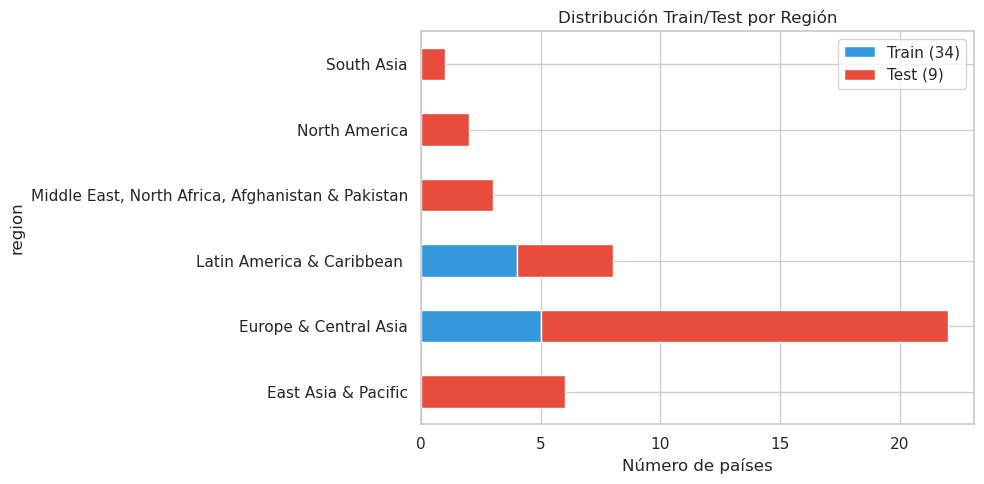


NOTA: Los 9 países TEST son 5 de Europa + 4 de Latinoamérica.
Estos países NO se usan en Fase 6. Se reservan para Fase 7.


In [2]:
# Visualización del split por región
fm = pd.read_csv(F5_BUNDLE / "phase6_feature_matrix.csv")
split_region = fm.groupby(["region", "split"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 5))
split_region.plot(kind="barh", stacked=True, ax=ax, color=["#3498db", "#e74c3c"])
ax.set_xlabel("Número de países")
ax.set_title("Distribución Train/Test por Región")
ax.legend(["Train (34)", "Test (9)"])
plt.tight_layout()
plt.show()

print()
print("NOTA: Los 9 países TEST son 5 de Europa + 4 de Latinoamérica.")
print("Estos países NO se usan en Fase 6. Se reservan para Fase 7.")

---
## 2. Variables del modelo

### 2.1 ¿Qué datos alimentan los modelos?

Hay tres tipos de variables:

| Tipo | Nombre | Qué mide | Ejemplo |
|------|--------|----------|---------|
| **X1** (Tratamiento) | Variables regulatorias | Cómo regula el país la IA | nº de leyes vinculantes |
| **X2** (Controles) | Variables socioeconómicas | Factores que también afectan el ecosistema | PIB per cápita, penetración internet |
| **Y** (Resultado) | Variables de ecosistema | Lo que queremos medir | Inversión, adopción, innovación |

**La pregunta central es:** Después de controlar por X2 (factores socioeconómicos),
¿la regulación (X1) se asocia con el ecosistema (Y)?

In [3]:
# Mostrar variables por rol según contrato de Fase 5
with open(F5_BUNDLE / "phase6_modeling_contract.yaml") as f:
    import yaml
    contract = yaml.safe_load(f)

roles = contract["variables_by_role"]

print("=" * 70)
print("VARIABLES POR ROL (definidas en Fase 5)")
print("=" * 70)

print()
print("X1 - VARIABLES REGULATORIAS (Tratamiento):")
for v in roles.get("X1_regulatory", []):
    print(f"  • {v}")

print()
print("X2 - CONTROLES SOCIOECONÓMICOS (12 variables):")
for v in roles.get("X2_control", []):
    print(f"  • {v}")

print()
print("Y - VARIABLES DE RESULTADO por sub-pregunta:")
for role, vars_list in roles.items():
    if role.startswith("Y_"):
        print(f"  {role}: {len(vars_list)} variables")
        for v in vars_list:
            print(f"    • {v}")

VARIABLES POR ROL (definidas en Fase 5)

X1 - VARIABLES REGULATORIAS (Tratamiento):
  • iapp_ley_ia_vigente
  • iapp_categoria_obligatoriedad
  • iapp_proyecto_ley_ia
  • iapp_modelo_gobernanza
  • iapp_n_leyes_relacionadas
  • iapp_n_autoridades

X2 - CONTROLES SOCIOECONÓMICOS (12 variables):
  • wb_gdp_per_capita_ppp
  • wb_internet_penetration
  • wb_tertiary_education_enrollment
  • wb_rd_expenditure_pct_gdp
  • wb_researchers_rd_per_million
  • wb_government_effectiveness
  • wb_rule_of_law
  • wb_regulatory_quality
  • wipo_in_score
  • wb_mobile_subscriptions_per100
  • wb_secure_servers_per_1m
  • wb_electric_consumption_kwh_pc

Y - VARIABLES DE RESULTADO por sub-pregunta:
  Y_Q1_investment: 5 variables
    • oxford_ind_company_investment_emerging_tech
    • oxford_ind_ai_unicorns_log
    • oxford_ind_non_ai_unicorns_log
    • oxford_ind_vc_availability
    • wipo_c_vencapdeal_score
  Y_Q1_or_control: 1 variables
    • wb_fdi_net_inflows
  Y_Q2_adoption: 9 variables
    • ms_h2

### 2.2 Cobertura de datos: ¿qué tan completos están?

No todos los países tienen datos para todas las variables Y.
Esto es CRÍTICO para entender por qué cada modelo usa un número diferente de países.

In [4]:
print("=" * 70)
print("COBERTURA DE DATOS CLAVE")
print("=" * 70)
print()
print("Variable | Países con datos | Cobertura")
print("-" * 50)
key_vars = roles.get("X1_regulatory", []) + ["n_binding", "n_non_binding"]
for v in key_vars:
    if v in fm.columns:
        n = fm[v].notna().sum()
        print(f"  {v:40s} | {n:2d}/43 | {n/43*100:.0f}%")

print()
print("DECISIÓN CLAVE: Usar variables AGREGADAS (n_binding, n_non_binding)")
print("que tienen 100% cobertura (43/43) en lugar de IAPP raw (solo 18/43).")
print("Esto permite usar todos los 43 países en los modelos.")

COBERTURA DE DATOS CLAVE

Variable | Países con datos | Cobertura
--------------------------------------------------
  iapp_ley_ia_vigente                      | 18/43 | 42%
  iapp_categoria_obligatoriedad            | 18/43 | 42%
  iapp_proyecto_ley_ia                     | 18/43 | 42%
  iapp_modelo_gobernanza                   | 18/43 | 42%
  iapp_n_leyes_relacionadas                | 18/43 | 42%
  iapp_n_autoridades                       | 18/43 | 42%
  n_binding                                | 43/43 | 100%
  n_non_binding                            | 43/43 | 100%

DECISIÓN CLAVE: Usar variables AGREGADAS (n_binding, n_non_binding)
que tienen 100% cobertura (43/43) en lugar de IAPP raw (solo 18/43).
Esto permite usar todos los 43 países en los modelos.


---
## 3. ¿Cómo evaluamos si un modelo es bueno sin grupo TEST?

Como explicamos en la Sección 1, NO usamos el grupo TEST en Fase 6.
En su lugar usamos **Cross-Validation (CV)**. A continuación explicamos CÓMO funciona.

### 3.1 ¿Qué es Cross-Validation?

Imaginemos que tenemos 40 países. En lugar de separar 32 para train y 8 para test (como haríamos normalmente), hacemos lo siguiente:

**5-fold CV (una sola repetición):**
1. Dividimos los 40 países en 5 grupos de 8 países cada uno
2. **Iteración 1:** Entrenamos con grupos 2+3+4+5 (32 países), evaluamos en grupo 1 (8 países)
3. **Iteración 2:** Entrenamos con grupos 1+3+4+5 (32 países), evaluamos en grupo 2 (8 países)
4. ...hasta 5 iteraciones
5. Promediamos las 5 métricas de evaluación

**5-fold CV repetida 10 veces:**
- Hacemos lo anterior 10 veces, cada vez con una división aleatoria diferente
- Total: 50 entrenamientos + 50 evaluaciones
- Resultado: métrica mucho más estable y confiable

**LOOCV (Leave-One-Out Cross-Validation):**
- Si tenemos 40 países, entrenamos 40 veces
- Cada vez dejamos 1 país fuera y evaluamos en ese país
- Muy útil cuando N es pequeño (como aquí)

### 3.2 ¿Por qué esto es SUFICIENTE?

| Método | Ventaja en nuestro caso |
|--------|------------------------|
| 5-fold x10 | Da una métrica promedio robusta con poca varianza |
| LOOCV | Aprovecha al máximo cada país; ideal para N<50 |
| Combinación de ambos | Si ambos dan resultados similares, tenemos confianza |

### 3.3 ¿Dónde NO usamos CV?

- **Q1, Q3, Q5, Q6 (regresión OLS):** Usamos **bootstrap 2000** en su lugar (re-muestreo con reemplazo 2000 veces para calcular intervalos de confianza)
- **Q4 (clustering):** Es un análisis NO supervisado; no hay "Y" que predecir, por lo tanto no necesita validación predictiva

---
## 4. Q4 — Tipos Regulatorios (Clustering)

### 4.1 ¿Qué pregunta responde?
**¿Existen grupos naturales de países según su perfil regulatorio de IA?**

### 4.2 ¿Es supervisado o no supervisado?
**NO supervisado.** El modelo NO predice una variable Y.
Solo agrupa países que son similares entre sí en sus características regulatorias.

### 4.3 ¿Qué países se usaron?

| Scope | N países | ¿Cuáles? | ¿Por qué? |
|-------|----------|----------|-----------|
| **N=43 (oficial)** | 43 | Todos los del dataset | Variables agregadas (n_binding, etc.) tienen 100% cobertura |
| **N=18 (complementario)** | 18 | Solo países con datos IAPP raw | Variables IAPP binarias solo existen para 18 países |

**Nota:** NO hay grupo TEST en clustering. Se usan todos los países disponibles.

### 4.4 ¿Qué modelo se usó y cómo se "entrenó"?

**K-Means (K=4):**
- **Input:** Matriz de características estandarizadas (z-score) de cada país
- **Proceso:** El algoritmo busca 4 "centros" (centroides) tal que cada país esté lo más cerca posible del centro de su grupo
- **No hay train/test:** El modelo ajusta los centroides a TODOS los datos simultáneamente

**HCA (Hierarchical Cluster Analysis):**
- **Input:** Matriz de distancias entre todos los pares de países
- **Proceso:** Comienza con cada país como su propio grupo, y va uniendo los más similares hasta formar 4 grupos
- **Método Ward:** Une grupos minimizando la varianza interna

### 4.5 ¿Cómo se evaluó la calidad?
**Silhouette Score:** Mide qué tan bien definidos están los clusters.
- Cercano a 1.0 = clusters muy definidos (bueno)
- Cercano a 0.0 = clusters ambiguos
- Negativo = países mal asignados

In [5]:
sil = pd.read_csv(OUTPUTS / "q4_silhouette_scores.csv")
print("=" * 70)
print("Q4: CALIDAD DEL CLUSTERING (Silhouette Score)")
print("=" * 70)
print()
print("Regla de interpretación:")
print("  > 0.50  → BUENO (clusters bien definidos)")
print("  0.25-0.50 → ACEPTABLE")
print("  < 0.25  → DÉBIL (clusters poco claros)")
print()
for _, row in sil.iterrows():
    score = row["silhouette_score"]
    label = "BUENO" if score > 0.5 else "ACEPTABLE" if score > 0.25 else "DÉBIL"
    print(f"  {row['method']:10s} ({row['scope']:12s}, K={row['k']}):  {score:.3f}  → {label}")

Q4: CALIDAD DEL CLUSTERING (Silhouette Score)

Regla de interpretación:
  > 0.50  → BUENO (clusters bien definidos)
  0.25-0.50 → ACEPTABLE
  < 0.25  → DÉBIL (clusters poco claros)

  kmeans     (n43_mixed   , K=4):  0.755  → BUENO
  hca        (n43_mixed   , K=4):  0.755  → BUENO
  kmeans     (n18_binary  , K=4):  0.765  → BUENO
  hca        (n18_binary  , K=4):  0.789  → BUENO


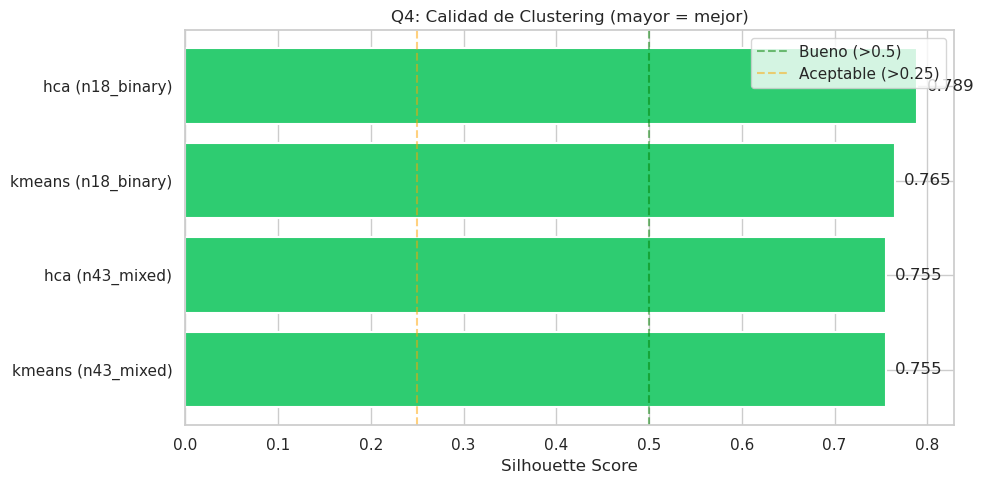

In [6]:
# Visualización silhouette
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#2ecc71" if s > 0.5 else "#f39c12" if s > 0.25 else "#e74c3c" for s in sil["silhouette_score"]]
bars = ax.barh(
    sil["method"] + " (" + sil["scope"] + ")",
    sil["silhouette_score"],
    color=colors, edgecolor="white", linewidth=1.5
)
ax.set_xlabel("Silhouette Score")
ax.set_title("Q4: Calidad de Clustering (mayor = mejor)")
ax.axvline(x=0.5, color="green", linestyle="--", alpha=0.5, label="Bueno (>0.5)")
ax.axvline(x=0.25, color="orange", linestyle="--", alpha=0.5, label="Aceptable (>0.25)")
ax.legend()
for bar, val in zip(bars, sil["silhouette_score"]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f"{val:.3f}", va="center")
plt.tight_layout()
plt.show()

In [7]:
# Clusters de países (K-Means N=43)
clusters = pd.read_csv(OUTPUTS / "q4_clusters.csv")
print("=" * 70)
print("Q4: PAISES POR CLUSTER (K-Means, K=4, N=43)")
print("=" * 70)
print()
for c in sorted(clusters["cluster_kmeans_n43"].unique()):
    iso3s = clusters[clusters["cluster_kmeans_n43"] == c]["iso3"].tolist()
    names = clusters[clusters["cluster_kmeans_n43"] == c]["country_name_canonical"].tolist()
    print(f"  Cluster {c} ({len(iso3s)} países):")
    for iso, name in zip(iso3s, names):
        flag = "  <<< CHILE" if iso == "CHL" else ""
        print(f"    {iso}  {name}{flag}")
    print()

chile_cluster = clusters[clusters["iso3"] == "CHL"]["cluster_kmeans_n43"].values[0]
cluster_chile_isos = clusters[clusters["cluster_kmeans_n43"] == chile_cluster]["iso3"].tolist()
print(f">>> CHILE está en el Cluster {chile_cluster}")
print(f"    Compañeros de cluster: {', '.join(cluster_chile_isos)}")

Q4: PAISES POR CLUSTER (K-Means, K=4, N=43)

  Cluster 0 (25 países):
    NOR  Norway
    IRL  Ireland
    FRA  France
    ESP  Spain
    NLD  Netherlands (Kingdom of the)
    QAT  Qatar
    BEL  Belgium
    CHE  Switzerland
    SWE  Sweden
    AUT  Austria
    HUN  Hungary
    DNK  Denmark
    DEU  Germany
    POL  Poland
    CZE  Czech Republic
    ITA  Italy
    BGR  Bulgaria
    FIN  Finland
    CRI  Costa Rica
    EST  Estonia
    MEX  Mexico
    URY  Uruguay
    GRC  Greece
    ROU  Romania
    HRV  Croatia

  Cluster 1 (3 países):
    ARE  United Arab Emirates
    USA  United States
    CHN  China

  Cluster 2 (12 países):
    SGP  Singapore
    NZL  New Zealand
    GBR  United Kingdom
    AUS  Australia
    ISR  Israel
    CAN  Canada
    TWN  Taiwan
    CHL  Chile  <<< CHILE
    IND  India
    ARG  Argentina
    BRA  Brazil
    COL  Colombia

  Cluster 3 (3 países):
    KOR  South Korea
    JPN  Japan
    PER  Peru

>>> CHILE está en el Cluster 2
    Compañeros de cluster: SGP

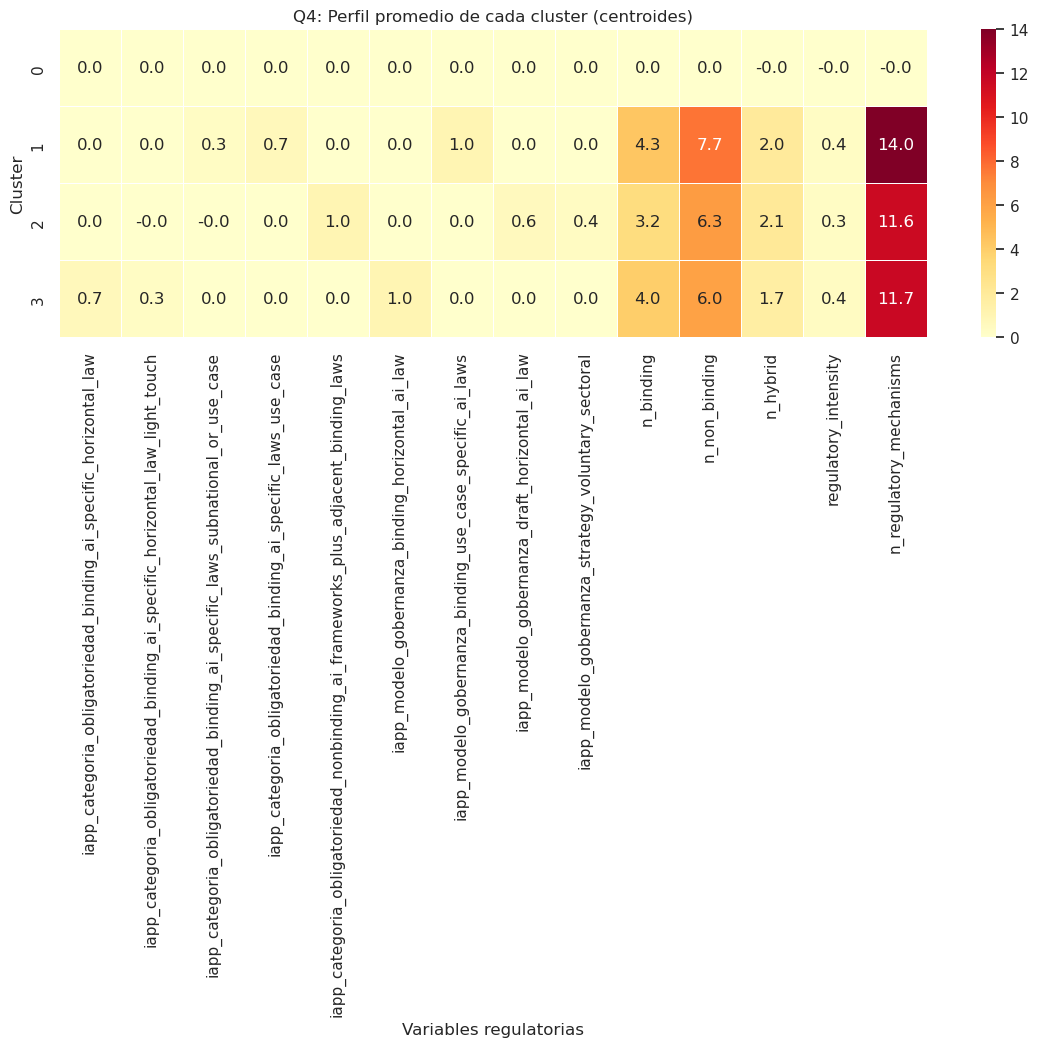


INTERPRETACIÓN: Cada fila es un cluster. Los valores muestran
el promedio de cada variable regulatoria en ese cluster.
Valores altos (rojo) = característica dominante del cluster.


In [8]:
# Heatmap de centroides
centroids = pd.read_csv(OUTPUTS / "q4_centroids.csv")
if len(centroids) > 0:
    fig, ax = plt.subplots(figsize=(14, 4))
    centroid_data = centroids.set_index("cluster_label")
    sns.heatmap(centroid_data, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax, linewidths=0.5)
    ax.set_title("Q4: Perfil promedio de cada cluster (centroides)")
    ax.set_xlabel("Variables regulatorias")
    ax.set_ylabel("Cluster")
    plt.tight_layout()
    plt.show()
    print()
    print("INTERPRETACIÓN: Cada fila es un cluster. Los valores muestran")
    print("el promedio de cada variable regulatoria en ese cluster.")
    print("Valores altos (rojo) = característica dominante del cluster.")

---
## 5. Q1 — Inversión en Ecosistema IA

### 5.1 ¿Qué pregunta responde?
**¿La regulación de IA se asocia con MENOR inversión en tecnología emergente?**

### 5.2 ¿Qué países se usaron para el TRAIN?

**Respuesta: Todos los países que tengan datos completos para la variable Y en cuestión.**

Q1 tiene **6 variables Y** de inversión. Cada una tiene un número diferente de países con datos completos:

| Variable Y | N efectivo | ¿Por qué varía? |
|------------|------------|-----------------|
| investment_emerging_tech | ~36 | Algunos países no reportan |
| AI unicorns (log) | ~36 | Transformación logarítmica |
| VC availability | ~36 | Datos faltantes |
| wipo_c_vencapdeal | ~36 | Datos faltantes |
| FDI net inflows | ~43 | Casi todos tienen |
| non-AI unicorns (log) | ~36 | Datos faltantes |

**¿Están Chile y los países TEST incluidos?**
- Sí, SIEMPRE que tengan datos para esa Y.
- Chile está incluido porque tiene datos y está en TRAIN.
- Los 9 países TEST también se incluyen SI tienen datos (pero no se les da un tratamiento especial).

### 5.3 ¿Qué modelos se entrenaron y CÓMO?

Para **cada una de las 6 variables Y**, se entrenaron 4 modelos:

#### Modelo A: OLS_full (Mínimos Cuadrados Ordinarios)
- **Fórmula:** Y = β₀ + β₁·X1 + β₂·X2 + ... + ε
- **Datos:** Todos los países con datos completos para esa Y (N ~ 36-43)
- **Proceso de train:**
  1. Se arma la matriz de datos (Y, X1 regulatorias, X2 controles)
  2. Se eliminan filas con datos faltantes (listwise deletion)
  3. Se ajusta la recta de regresión que minimiza el error cuadrático medio
- **Validación:**
  - **Bootstrap 2000:** Se repite el paso 3 dos mil veces, cada vez tomando una muestra aleatoria CON reemplazo de los mismos países. Esto genera un intervalo de confianza robusto (IC95).
  - No se usa CV porque bootstrap es más apropiado para regresión con coeficientes.

#### Modelo B: OLS_only_X2 (solo controles)
- Igual que OLS_full pero SIN las variables X1 regulatorias.
- **Propósito:** Comparar el R² con y sin regulación para ver cuánto aporta.

#### Modelo C: Ridge (Regresión con penalización L2)
- **Datos:** Mismos que OLS_full
- **Proceso de train:**
  1. Se estandarizan las variables X (media 0, desvío 1)
  2. Se ajusta la regresión penalizando coeficientes grandes (alpha=1.0)
  3. La penalización reduce el sobreajuste cuando hay muchas variables
- **Validación:**
  - **5-fold CV repetida 10 veces** (50 entrenamientos)
  - **LOOCV** (N entrenamientos, dejando 1 país afuera cada vez)
  - Métrica: R² promedio y desvío estándar

#### Modelo D: Lasso (Regresión con penalización L1)
- Similar a Ridge pero con penalización L1 (alpha=0.1)
- Puede "anular" variables irrelevantes llevando coeficientes a exactamente 0
- Misma validación que Ridge

### 5.4 ¿Cómo se corrige por comparaciones múltiples?

Como probamos 6 variables Y, podríamos obtener un p-valor <0.05 por pura casualidad.
Usamos **FDR Benjamini-Hochberg** para ajustar los p-valores.

### 5.5 ¿Qué resultados se obtuvieron?

Q1: RESULTADOS — Asociación entre regulación (n_binding) e inversión

Variable X1 analizada: n_binding
Interpretación del gráfico:
  • Punto a la IZQUIERDA de la línea roja → más regulación = MENOS inversión
  • Punto a la DERECHA de la línea roja → más regulación = MÁS inversión
  • Barra que NO toca la línea roja → asociación estadísticamente significativa (p<0.05)

Número de modelos entrenados: 6 variables Y × 4 modelos = ~24 ajustes
Países por modelo: N efectivo entre 34 y 36



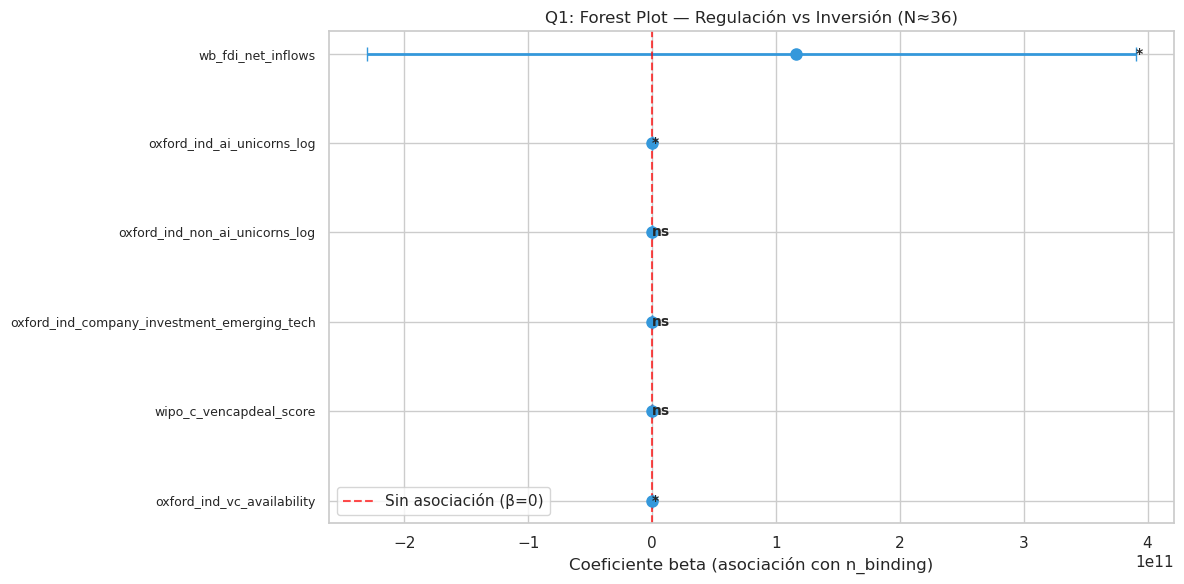

In [9]:
q1 = pd.read_csv(OUTPUTS / "q1_results.csv")

# Filtrar solo filas de OLS_full con coeficientes válidos
q1_ols = q1[(q1["model"] == "OLS_full") & (q1["x_var"] != "const") & q1["coefficient"].notna()].copy()

# Determinar nombre de la variable focal (puede ser n_binding o n_binding_z)
focal = "n_binding_z" if "n_binding_z" in q1_ols["x_var"].unique() else "n_binding"
focal_rows = q1_ols[q1_ols["x_var"] == focal].copy()
focal_rows = focal_rows.sort_values("coefficient")

print("=" * 70)
print("Q1: RESULTADOS — Asociación entre regulación (n_binding) e inversión")
print("=" * 70)
print()
print("Variable X1 analizada:", focal)
print("Interpretación del gráfico:")
print("  • Punto a la IZQUIERDA de la línea roja → más regulación = MENOS inversión")
print("  • Punto a la DERECHA de la línea roja → más regulación = MÁS inversión")
print("  • Barra que NO toca la línea roja → asociación estadísticamente significativa (p<0.05)")
print()
print(f"Número de modelos entrenados: {len(q1_ols['y_var'].unique())} variables Y × 4 modelos = ~24 ajustes")
print(f"Países por modelo: N efectivo entre {q1_ols['n_effective'].min()} y {q1_ols['n_effective'].max()}")
print()

if len(focal_rows) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    y_pos = range(len(focal_rows))

    ax.errorbar(
        focal_rows["coefficient"], y_pos,
        xerr=[focal_rows["coefficient"] - focal_rows["ci95_lower"],
              focal_rows["ci95_upper"] - focal_rows["coefficient"]],
        fmt="o", color="#3498db", ecolor="#3498db", elinewidth=2, capsize=5, markersize=8
    )

    ax.axvline(x=0, color="red", linestyle="--", alpha=0.7, label="Sin asociación (β=0)")
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels([y[:45] for y in focal_rows["y_var"]], fontsize=9)
    ax.set_xlabel("Coeficiente beta (asociación con n_binding)")
    n_eff = int(focal_rows["n_effective"].iloc[0])
    ax.set_title(f"Q1: Forest Plot — Regulación vs Inversión (N≈{n_eff})")

    for i, (_, row) in enumerate(focal_rows.iterrows()):
        p = row.get("p_value", 1)
        if p < 0.001:
            sig = "***"
        elif p < 0.01:
            sig = "**"
        elif p < 0.05:
            sig = "*"
        else:
            sig = "ns"
        ax.text(row["ci95_upper"] + 0.02, i, sig, va="center", fontsize=10, fontweight="bold")

    ax.legend()
    plt.tight_layout()
    plt.show()

In [10]:
# Tabla detallada Q1
print("=" * 70)
print("Q1: TABLA DE COEFICIENTES DETALLADA (OLS_full + bootstrap 2000)")
print("=" * 70)
print()
print("Columnas:")
print("  • Coef (beta): Tamaño de la asociación. Unidades: desvíos estándar de Y por cada desvío estándar de X1")
print("  • IC95 inf/sup: Intervalo de confianza 95% (bootstrap 2000 iteraciones)")
print("  • p-valor: Probabilidad de ver este resultado por azar")
print("  • N: Número de países usados en ESTE modelo")
print("  • R²: Qué tan bien explica el modelo la variable Y (0 = nada, 1 = perfecto)")
print()

tabla = focal_rows[["y_var", "coefficient", "ci95_lower", "ci95_upper", "p_value", "n_effective", "r2"]].copy()
tabla.columns = ["Variable Y", "Coef beta", "IC95 inf", "IC95 sup", "p-valor", "N", "R2"]
display(tabla.round(4))

print()
print("SIGNIFICANCIA: * p<0.05, ** p<0.01, *** p<0.001, ns = no significativo")
print()
print("RECUERDE: Estos coeficientes son de ASOCIACIÓN, no causalidad.")
print("Un beta negativo significa: 'países con más leyes vinculantes tienden a tener")
print("menor inversión, DESPUÉS de controlar por PIB, educación, etc.'")

Q1: TABLA DE COEFICIENTES DETALLADA (OLS_full + bootstrap 2000)

Columnas:
  • Coef (beta): Tamaño de la asociación. Unidades: desvíos estándar de Y por cada desvío estándar de X1
  • IC95 inf/sup: Intervalo de confianza 95% (bootstrap 2000 iteraciones)
  • p-valor: Probabilidad de ver este resultado por azar
  • N: Número de países usados en ESTE modelo
  • R²: Qué tan bien explica el modelo la variable Y (0 = nada, 1 = perfecto)



,Variable Y,Coef beta,IC95 inf,IC95 sup,p-valor,N,R2
159,oxford_ind_vc_availability,-3.493050e+01,-1.806667e+02,4.091560e+01,0.0412,36,0.8557
212,wipo_c_vencapdeal_score,-2.816650e+01,-2.028521e+02,8.245930e+01,0.1124,34,0.8588
0,oxford_ind_company_investment_emerging_tech,-8.093600e+00,-9.067150e+01,5.129160e+01,0.4418,36,0.8893
106,oxford_ind_non_ai_unicorns_log,1.671210e+01,-7.675390e+01,1.055237e+02,0.2329,36,0.8438
53,oxford_ind_ai_unicorns_log,2.239950e+01,-5.955410e+01,1.001993e+02,0.0398,36,0.8881
265,wb_fdi_net_inflows,1.160483e+11,-2.297755e+11,3.903017e+11,0.0200,36,0.7212



SIGNIFICANCIA: * p<0.05, ** p<0.01, *** p<0.001, ns = no significativo

RECUERDE: Estos coeficientes son de ASOCIACIÓN, no causalidad.
Un beta negativo significa: 'países con más leyes vinculantes tienden a tener
menor inversión, DESPUÉS de controlar por PIB, educación, etc.'


In [11]:
# Consistencia de signo Q1
q1_cons = pd.read_csv(OUTPUTS / "q1_consistency.csv")
print("=" * 70)
print("Q1: CONSISTENCIA DE SIGNO ENTRE VARIABLES Y")
print("=" * 70)
print()
print("Pregunta: ¿Cuándo aumenta n_binding, TODAS las variables de")
print("inversión se mueven en la misma dirección?")
print()
for _, row in q1_cons.iterrows():
    direction = row.get("direction_summary", "N/A")
    n_neg = int(row.get("n_y_negative", 0))
    n_pos = int(row.get("n_y_positive", 0))
    n_sig = int(row.get("n_y_significant_05", 0))
    print(f"  Variable X1: {row['x_var']}")
    print(f"    Y con beta negativo: {n_neg} | Y con beta positivo: {n_pos} | Significativas: {n_sig}")
    print(f"    Dirección general: {direction}")
    print()

Q1: CONSISTENCIA DE SIGNO ENTRE VARIABLES Y

Pregunta: ¿Cuándo aumenta n_binding, TODAS las variables de
inversión se mueven en la misma dirección?

  Variable X1: n_binding
    Y con beta negativo: 3 | Y con beta positivo: 3 | Significativas: 3
    Dirección general: mixed

  Variable X1: n_non_binding
    Y con beta negativo: 3 | Y con beta positivo: 3 | Significativas: 2
    Dirección general: mixed

  Variable X1: n_hybrid
    Y con beta negativo: 1 | Y con beta positivo: 5 | Significativas: 3
    Dirección general: robust_positive

  Variable X1: regulatory_intensity
    Y con beta negativo: 4 | Y con beta positivo: 2 | Significativas: 2
    Dirección general: robust_negative

  Variable X1: n_regulatory_mechanisms
    Y con beta negativo: 1 | Y con beta positivo: 5 | Significativas: 3
    Dirección general: robust_positive



### 5.6 PSM Exploratorio (Propensity Score Matching)

**¿Qué intenta hacer?**
Comparar países CON ley de IA vs SIN ley de IA, emparejados por características socioeconómicas similares.

**¿Por qué es EXPLORATORIO?**
- Solo 6 países tienen ley de IA vigente → muy pocos pares posibles
- Resultado: N insuficiente para conclusiones sólidas

Q1: PROPENSITY SCORE MATCHING (Exploratorio)

PSM compara países CON ley IA vs SIN ley IA,
emparejados por características socioeconómicas similares.

RESULTADO: N insuficiente para PSM concluyente.
Solo pocos países tratados -> muy pocos pares posibles.
PSM queda como 'exploratorio' - NO es concluyente.

BALANCE DE COVARIABLES (Standardized Mean Difference):
  SMD < 0.1 = buen balance
  SMD > 0.2 = desbalance preocupante


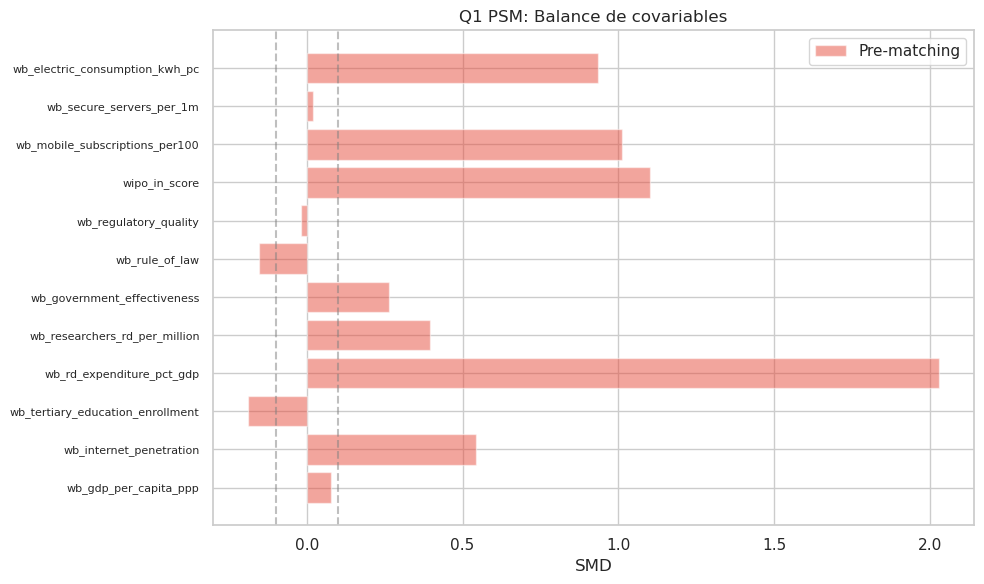

In [12]:
psm = pd.read_csv(OUTPUTS / "q1_psm_matched_pairs.csv")
print("=" * 70)
print("Q1: PROPENSITY SCORE MATCHING (Exploratorio)")
print("=" * 70)
print()
print("PSM compara países CON ley IA vs SIN ley IA,")
print("emparejados por características socioeconómicas similares.")
print()
if "status" in psm.columns and psm["status"].iloc[0] == "insufficient_n":
    print("RESULTADO: N insuficiente para PSM concluyente.")
    print(f"Solo {psm.get('n_treated', ['?'])[0] if 'n_treated' in psm.columns else 'pocos'} países tratados -> muy pocos pares posibles.")
    print("PSM queda como 'exploratorio' - NO es concluyente.")
else:
    display(psm)

psm_bal = pd.read_csv(OUTPUTS / "q1_psm_balance_diagnostics.csv")
if "smd_pre" in psm_bal.columns and psm_bal["smd_pre"].notna().any():
    print()
    print("BALANCE DE COVARIABLES (Standardized Mean Difference):")
    print("  SMD < 0.1 = buen balance")
    print("  SMD > 0.2 = desbalance preocupante")
    fig, ax = plt.subplots(figsize=(10, 6))
    x = range(len(psm_bal))
    ax.barh(x, psm_bal["smd_pre"], alpha=0.5, label="Pre-matching", color="#e74c3c")
    if "smd_post" in psm_bal.columns and psm_bal["smd_post"].notna().any():
        ax.barh(x, psm_bal["smd_post"], alpha=0.5, label="Post-matching", color="#2ecc71")
    ax.set_yticks(list(x))
    ax.set_yticklabels(psm_bal["variable"], fontsize=8)
    ax.axvline(x=0.1, color="gray", linestyle="--", alpha=0.5)
    ax.axvline(x=-0.1, color="gray", linestyle="--", alpha=0.5)
    ax.set_xlabel("SMD")
    ax.set_title("Q1 PSM: Balance de covariables")
    ax.legend()
    plt.tight_layout()
    plt.show()

---
## 6. Q3 — Innovación

### 6.1 ¿Qué pregunta responde?
**¿La regulación de IA se asocia con menor innovación tecnológica?**

### 6.2 ¿Qué países se usaron?

Q3 divide las variables Y en dos grupos ("tiers") según disponibilidad de datos:

| Tier | Variables Y | N países | ¿Por qué? |
|------|-------------|----------|-----------|
| **Primary** | 6 variables (wipo_out_score, oxford_total_score, etc.) | 40-42 | Buena cobertura global |
| **Auxiliary** | 1 variable (Stanford publications) | 26 | Solo algunos países reportan |

**¿Chile está?** Sí, en ambos tiers (tiene datos).
**¿Países TEST?** Sí, si tienen datos para la variable en cuestión.

### 6.3 ¿Qué modelos se entrenaron y CÓMO?

Para **cada variable Y en cada tier**, se entrenaron 3 modelos:

#### Modelo A: OLS_full + bootstrap 2000
- **Exactamente igual que Q1**
- **Train:** Todos los países con datos completos para esa Y
- **Validación:** Bootstrap 2000 iteraciones para IC95

#### Modelo B: Ridge + CV
- **Exactamente igual que Q1**
- **Train:** Mismos datos
- **Validación:** 5-fold CV repetida 10 veces + LOOCV

#### Modelo C: GBR (Gradient Boosting Regressor)
- **Tipo:** Modelo NO lineal basado en árboles de decisión
- **Hiperparámetros fijos:** n_estimators=200, max_depth=3, learning_rate=0.05
- **Train:** Mismos datos que OLS
- **Validación:** 5-fold CV repetida 10 veces + LOOCV
- **Métrica:** R² (cuánta varianza de Y explica el modelo)

### 6.4 ¿Por qué GBR?
OLS y Ridge asumen una relación LINEAL entre X e Y.
GBR captura relaciones NO lineales (por ejemplo, que el efecto de la regulación
cambie según el nivel de desarrollo del país).

Si GBR da un R² mucho mayor que OLS, sugiere que la relación es no lineal.
Si dan resultados similares, la relación lineal es una buena aproximación.

Q3: RESULTADOS — Regulación vs Innovación (Tier Primary)

Variable X1: n_binding
Modelos entrenados: 7 Y × 3 modelos = ~18 ajustes (solo primary)
N por modelo: entre 35 y 36 países

Mismo análisis que Q1 pero con variables de INNOVACIÓN



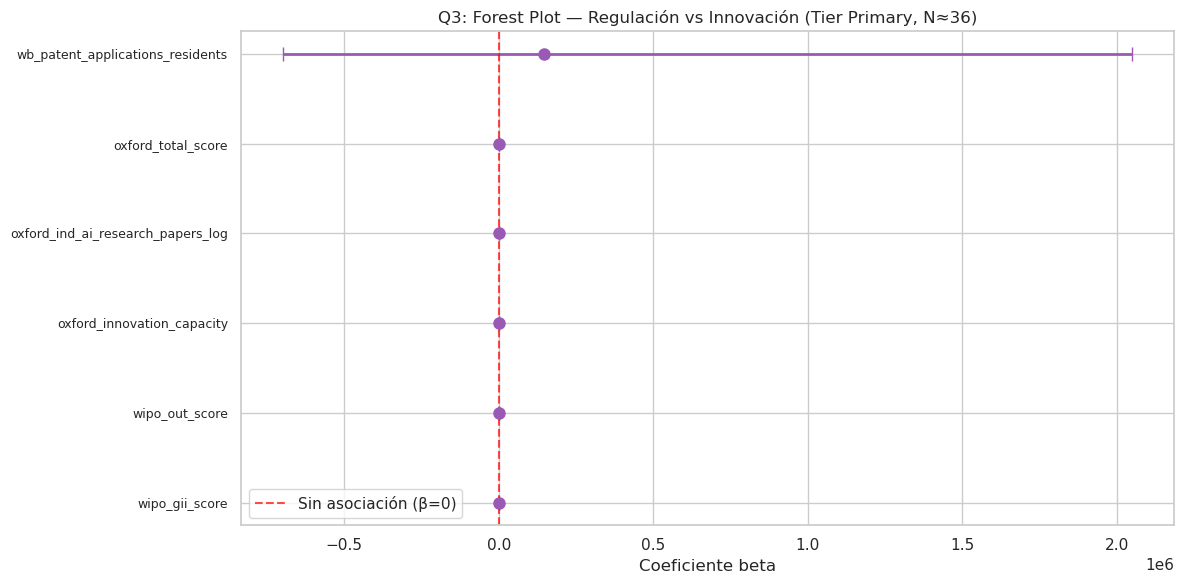

In [13]:
q3 = pd.read_csv(OUTPUTS / "q3_results.csv")

focal = "n_binding_z" if "n_binding_z" in q3["x_var"].unique() else "n_binding"
q3_primary = q3[
    (q3["model"] == "OLS_full") &
    (q3["x_var"] == focal) &
    (q3["tier"] == "primary") &
    q3["coefficient_or_importance"].notna()
].copy()
q3_primary = q3_primary.sort_values("coefficient_or_importance")

print("=" * 70)
print("Q3: RESULTADOS — Regulación vs Innovación (Tier Primary)")
print("=" * 70)
print()
print(f"Variable X1: {focal}")
print(f"Modelos entrenados: {q3['y_var'].nunique()} Y × 3 modelos = ~18 ajustes (solo primary)")
print(f"N por modelo: entre {q3_primary['n_effective'].min()} y {q3_primary['n_effective'].max()} países")
print()
print("Mismo análisis que Q1 pero con variables de INNOVACIÓN")
print()

if len(q3_primary) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    y_pos = range(len(q3_primary))
    has_ci = q3_primary["ci95_lower"].notna().any()
    if has_ci:
        ax.errorbar(
            q3_primary["coefficient_or_importance"], y_pos,
            xerr=[q3_primary["coefficient_or_importance"] - q3_primary["ci95_lower"],
                  q3_primary["ci95_upper"] - q3_primary["coefficient_or_importance"]],
            fmt="o", color="#9b59b6", ecolor="#9b59b6", elinewidth=2, capsize=5, markersize=8
        )
    ax.axvline(x=0, color="red", linestyle="--", alpha=0.7, label="Sin asociación (β=0)")
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels([y[:40] for y in q3_primary["y_var"]], fontsize=9)
    ax.set_xlabel("Coeficiente beta")
    n_eff = int(q3_primary["n_effective"].iloc[0])
    ax.set_title(f"Q3: Forest Plot — Regulación vs Innovación (Tier Primary, N≈{n_eff})")
    ax.legend()
    plt.tight_layout()
    plt.show()

In [14]:
# Consistencia Q3
q3_cons = pd.read_csv(OUTPUTS / "q3_consistency.csv")
print("=" * 70)
print("Q3: CONSISTENCIA DE SIGNO")
print("=" * 70)
print()
for _, row in q3_cons.iterrows():
    tier = row.get("tier", "N/A")
    n_neg = int(row.get("n_y_negative", 0))
    n_pos = int(row.get("n_y_positive", 0))
    n_sig = int(row.get("n_y_significant_05", 0))
    print(f"  Tier: {tier} | Variable X1: {row['x_var']}")
    print(f"    Y negativos: {n_neg} | Y positivos: {n_pos} | Significativos: {n_sig}")
    print()

Q3: CONSISTENCIA DE SIGNO

  Tier: primary | Variable X1: n_binding
    Y negativos: 0 | Y positivos: 6 | Significativos: 0

  Tier: auxiliary_low_n | Variable X1: n_binding
    Y negativos: 0 | Y positivos: 1 | Significativos: 0

  Tier: primary | Variable X1: n_non_binding
    Y negativos: 6 | Y positivos: 0 | Significativos: 0

  Tier: auxiliary_low_n | Variable X1: n_non_binding
    Y negativos: 1 | Y positivos: 0 | Significativos: 0

  Tier: primary | Variable X1: n_hybrid
    Y negativos: 3 | Y positivos: 3 | Significativos: 0

  Tier: auxiliary_low_n | Variable X1: n_hybrid
    Y negativos: 0 | Y positivos: 1 | Significativos: 0

  Tier: primary | Variable X1: regulatory_intensity
    Y negativos: 6 | Y positivos: 0 | Significativos: 0

  Tier: auxiliary_low_n | Variable X1: regulatory_intensity
    Y negativos: 1 | Y positivos: 0 | Significativos: 0

  Tier: primary | Variable X1: n_regulatory_mechanisms
    Y negativos: 0 | Y positivos: 6 | Significativos: 0

  Tier: auxiliary

---
## 7. Q2 — Adopción Empresarial de IA

### 7.1 ¿Qué pregunta responde?
**¿La regulación de IA se asocia con menor adopción de IA por empresas?**

### 7.2 ¿Qué países se usaron?

Q2 tiene **7 variables Y** de adopción empresarial.

| Variable Y | N efectivo | Ejemplo |
|------------|------------|---------|
| ms_h2_2025_ai_diffusion_pct | 35 | Difusión de IA empresarial (H2 2025) |
| ms_h1_2025_ai_diffusion_pct | ~35 | Difusión de IA empresarial (H1 2025) |
| anthropic_usage_pct | ~35 | Uso reportado por Anthropic |
| anthropic_collaboration_pct | ~35 | Colaboración reportada por Anthropic |
| oecd_5_ict_business_oecd_biz_ai_pct | ~20 | Uso de IA en negocios (OECD) |
| oxford_public_sector_adoption | ~43 | Adopción sector público (reusada en Q6) |
| oxford_ind_adoption_emerging_tech | ~43 | Adopción tecnología emergente (reusada en Q5) |

**¿Chile?** Sí, donde tiene datos.
**¿Países TEST?** Sí, si tienen datos.

### 7.3 ¿Qué modelos se entrenaron y CÓMO?

A diferencia de Q1/Q3 (regresión continua), Q2 es **CLASIFICACIÓN**:
- **Y binaria:** 1 = alta adopción (sobre la mediana), 0 = baja adopción (bajo la mediana)

#### Modelo A: Logistic Regression
- **Tipo:** Regresión logística (clasificador lineal)
- **Hiperparámetros:** penalty=l2, C=1.0, class_weight=balanced
- **Proceso de train:**
  1. Para cada variable Y, se calcula la mediana
  2. Se convierte Y en binaria (1 si ≥ mediana, 0 si < mediana)
  3. Se entrena el clasificador con TODOS los países que tengan datos
- **Validación:**
  - **5-fold CV repetida 10 veces** → 50 entrenamientos; métrica = AUC
  - **LOOCV** → N entrenamientos; métrica = AUC
  - **Matriz de confusión:** TP, TN, FP, FN (usando StratifiedKFold)

#### Modelo B: Random Forest
- **Tipo:** Bosque de árboles de decisión (clasificador NO lineal)
- **Hiperparámetros fijos:** n_estimators=300, max_depth=4, min_samples_leaf=3
- **Train:** Mismos datos binarizados que Logistic
- **Validación:** 5-fold CV x10 + LOOCV; métrica = AUC
- **Feature importance:** Cuánto contribuye cada X a las decisiones del bosque

### 7.4 ¿Cómo se evalúa un clasificador?
**AUC (Area Under the ROC Curve):**
- AUC = 0.5 → el modelo no discrimina (equivale a lanzar una moneda)
- AUC = 0.7 → aceptable
- AUC = 0.8 → bueno
- AUC > 0.85 → excelente

In [15]:
q2 = pd.read_csv(OUTPUTS / "q2_results.csv")
q2_meta = q2[q2["x_var"] == "__model_metadata__"].copy()

print("=" * 70)
print("Q2: MÉTRICAS DE CLASIFICACIÓN POR MODELO Y VARIABLE Y")
print("=" * 70)
print()
print("AUC = Area Under the ROC Curve")
print("  0.5 = azar | 0.7 = aceptable | 0.8 = bueno | >0.85 = excelente")
print()
print("Para CADA variable Y se entrenaron 2 modelos (Logistic + RandomForest)")
print("Cada modelo se validó con 5-fold CV × 10 repeticiones + LOOCV")
print()

cols_show = ["y_var", "model", "auc_cv_5fold_mean", "auc_cv_5fold_std", "auc_loocv", "n_effective", "n_class_0", "n_class_1"]
available = [c for c in cols_show if c in q2_meta.columns]
if len(available) > 0:
    display(q2_meta[available].round(3))

print()
print("INTERPRETACIÓN:")
for _, row in q2_meta.iterrows():
    m = row["model"]
    y = row["y_var"][:40]
    auc = row.get("auc_cv_5fold_mean", np.nan)
    n = int(row.get("n_effective", 0))
    if auc >= 0.85:
        calif = "EXCELENTE"
    elif auc >= 0.80:
        calif = "BUENO"
    elif auc >= 0.70:
        calif = "ACEPTABLE"
    elif auc >= 0.50:
        calif = "DÉBIL"
    else:
        calif = "NO MEJOR QUE AZAR"
    print(f"  {m:12s} | {y:40s} | AUC={auc:.3f} | N={n:2d} | {calif}")

Q2: MÉTRICAS DE CLASIFICACIÓN POR MODELO Y VARIABLE Y

AUC = Area Under the ROC Curve
  0.5 = azar | 0.7 = aceptable | 0.8 = bueno | >0.85 = excelente

Para CADA variable Y se entrenaron 2 modelos (Logistic + RandomForest)
Cada modelo se validó con 5-fold CV × 10 repeticiones + LOOCV



,y_var,model,auc_cv_5fold_mean,auc_cv_5fold_std,auc_loocv,n_effective,n_class_0,n_class_1
0,ms_h2_2025_ai_diffusion_pct,Logistic,0.925,0.136,NaN,35,17.0,18.0
18,ms_h2_2025_ai_diffusion_pct,RandomForest,0.880,0.133,NaN,35,NaN,NaN
36,ms_h1_2025_ai_diffusion_pct,Logistic,0.848,0.172,NaN,35,17.0,18.0
54,ms_h1_2025_ai_diffusion_pct,RandomForest,0.842,0.173,NaN,35,NaN,NaN
72,anthropic_usage_pct,Logistic,0.637,0.247,NaN,35,17.0,18.0
90,anthropic_usage_pct,RandomForest,0.569,0.218,NaN,35,NaN,NaN
108,anthropic_collaboration_pct,Logistic,NaN,NaN,NaN,35,4.0,31.0
126,anthropic_collaboration_pct,RandomForest,NaN,NaN,NaN,35,NaN,NaN
144,oecd_5_ict_business_oecd_biz_ai_pct,Logistic,NaN,NaN,NaN,26,13.0,13.0
162,oecd_5_ict_business_oecd_biz_ai_pct,RandomForest,NaN,NaN,NaN,26,NaN,NaN



INTERPRETACIÓN:
  Logistic     | ms_h2_2025_ai_diffusion_pct              | AUC=0.925 | N=35 | EXCELENTE
  RandomForest | ms_h2_2025_ai_diffusion_pct              | AUC=0.880 | N=35 | EXCELENTE
  Logistic     | ms_h1_2025_ai_diffusion_pct              | AUC=0.848 | N=35 | BUENO
  RandomForest | ms_h1_2025_ai_diffusion_pct              | AUC=0.842 | N=35 | BUENO
  Logistic     | anthropic_usage_pct                      | AUC=0.637 | N=35 | DÉBIL
  RandomForest | anthropic_usage_pct                      | AUC=0.569 | N=35 | DÉBIL
  Logistic     | anthropic_collaboration_pct              | AUC=nan | N=35 | NO MEJOR QUE AZAR
  RandomForest | anthropic_collaboration_pct              | AUC=nan | N=35 | NO MEJOR QUE AZAR
  Logistic     | oecd_5_ict_business_oecd_biz_ai_pct      | AUC=nan | N=26 | NO MEJOR QUE AZAR
  RandomForest | oecd_5_ict_business_oecd_biz_ai_pct      | AUC=nan | N=26 | NO MEJOR QUE AZAR
  Logistic     | oxford_public_sector_adoption            | AUC=0.491 | N=36 | NO MEJ

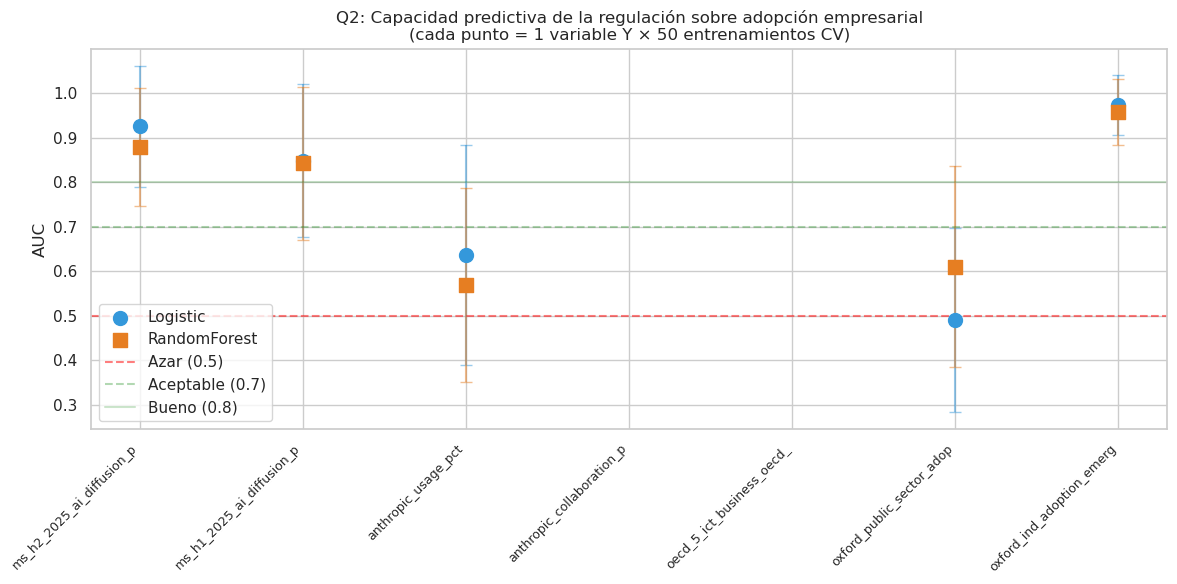

In [16]:
# Gráfico de AUC
fig, ax = plt.subplots(figsize=(12, 6))
for model_name, color, marker in [("Logistic", "#3498db", "o"), ("RandomForest", "#e67e22", "s")]:
    subset = q2_meta[q2_meta["model"] == model_name]
    if len(subset) > 0 and "auc_cv_5fold_mean" in subset.columns:
        xs = range(len(subset))
        ax.scatter(xs, subset["auc_cv_5fold_mean"], s=100, c=color, marker=marker, label=model_name, zorder=5)
        if "auc_cv_5fold_std" in subset.columns:
            ax.errorbar(xs, subset["auc_cv_5fold_mean"], yerr=subset["auc_cv_5fold_std"],
                        fmt="none", ecolor=color, elinewidth=1.5, capsize=4, alpha=0.5)

ax.axhline(y=0.5, color="red", linestyle="--", alpha=0.5, label="Azar (0.5)")
ax.axhline(y=0.7, color="green", linestyle="--", alpha=0.3, label="Aceptable (0.7)")
ax.axhline(y=0.8, color="green", linestyle="-", alpha=0.2, label="Bueno (0.8)")
y_vars = q2_meta["y_var"].unique()
ax.set_xticks(range(len(y_vars)))
ax.set_xticklabels([y[:25] for y in y_vars], rotation=45, ha="right", fontsize=9)
ax.set_ylabel("AUC")
ax.set_title("Q2: Capacidad predictiva de la regulación sobre adopción empresarial\n(cada punto = 1 variable Y × 50 entrenamientos CV)")
ax.legend()
plt.tight_layout()
plt.show()

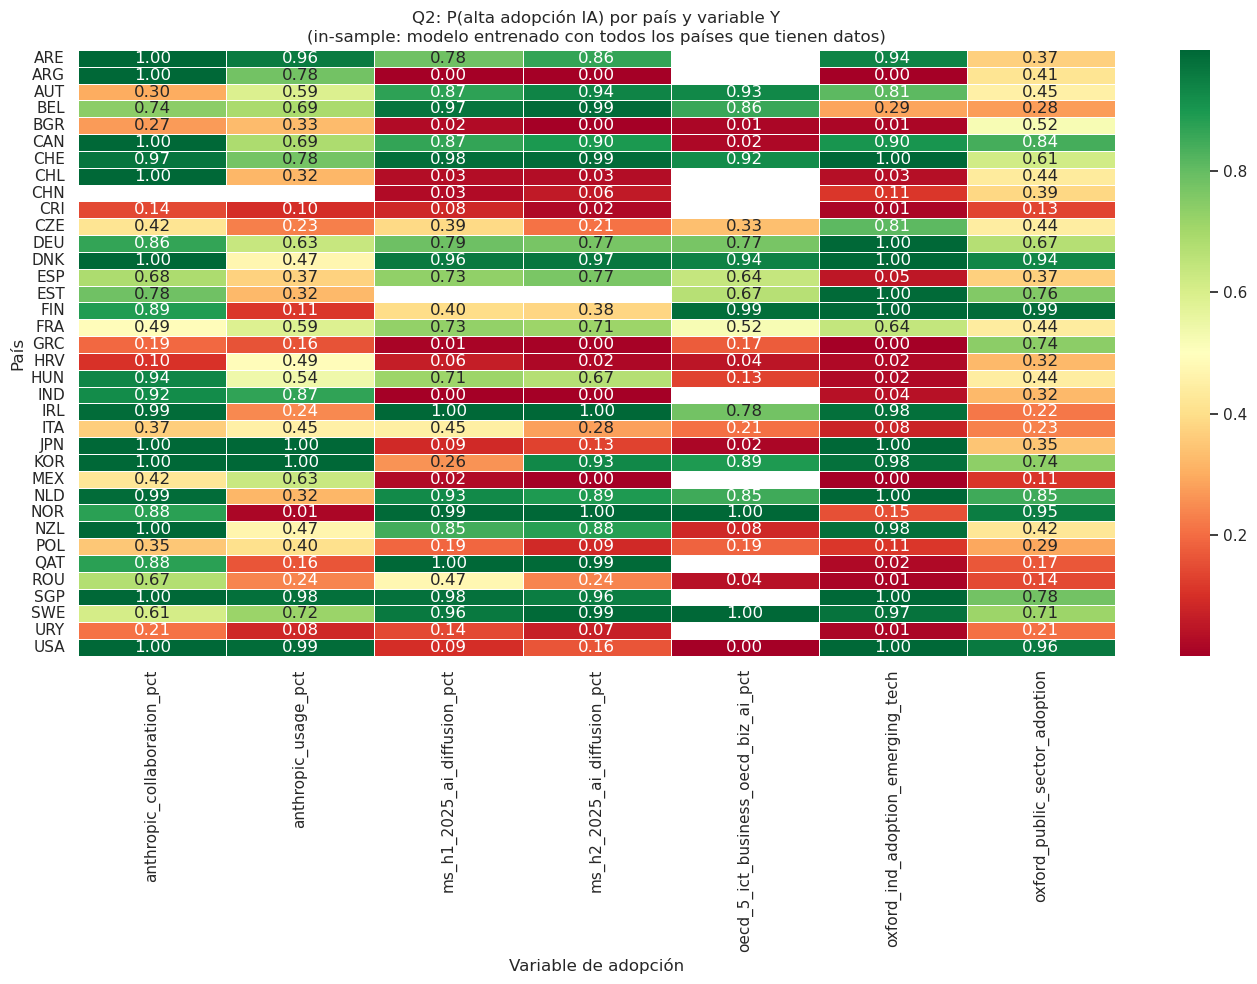


CHILE — Probabilidad predicha de ALTA adopción (in-sample)

NOTA: 'In-sample' significa que el modelo fue entrenado INCLUYENDO a Chile.
Por eso estas probabilidades NO son una prueba independiente.
Sirven para posicionar a Chile relativamente a otros países.

  ms_h2_2025_ai_diffusion_pct                        → P(alta adopción) = 0.030
  ms_h1_2025_ai_diffusion_pct                        → P(alta adopción) = 0.030
  anthropic_usage_pct                                → P(alta adopción) = 0.317
  anthropic_collaboration_pct                        → P(alta adopción) = 0.999
  oxford_public_sector_adoption                      → P(alta adopción) = 0.437
  oxford_ind_adoption_emerging_tech                  → P(alta adopción) = 0.035


In [17]:
# Predicciones por país (in-sample: modelo entrenado con todos los datos disponibles)
q2_pred = pd.read_csv(OUTPUTS / "q2_predictions_per_country.csv")
if len(q2_pred) > 0:
    pivot = q2_pred.pivot_table(index="iso3", columns="y_var", values="p_high_adoption")
    fig, ax = plt.subplots(figsize=(14, 10))
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn", center=0.5, ax=ax, linewidths=0.5)
    ax.set_title("Q2: P(alta adopción IA) por país y variable Y\n(in-sample: modelo entrenado con todos los países que tienen datos)")
    ax.set_xlabel("Variable de adopción")
    ax.set_ylabel("País")
    plt.tight_layout()
    plt.show()

    chile_pred = q2_pred[q2_pred["iso3"] == "CHL"]
    if len(chile_pred) > 0:
        print()
        print("=" * 70)
        print("CHILE — Probabilidad predicha de ALTA adopción (in-sample)")
        print("=" * 70)
        print()
        print("NOTA: 'In-sample' significa que el modelo fue entrenado INCLUYENDO a Chile.")
        print("Por eso estas probabilidades NO son una prueba independiente.")
        print("Sirven para posicionar a Chile relativamente a otros países.")
        print()
        for _, r in chile_pred.iterrows():
            print(f"  {r['y_var'][:50]:50s} → P(alta adopción) = {r['p_high_adoption']:.3f}")

---
## 8. Q5 — Uso de IA por la Población

### 8.1 ¿Qué pregunta responde?
**¿La regulación de IA se asocia con el uso de IA por parte de la ciudadanía?**

### 8.2 ¿Qué países se usaron?

Q5 reusa 3 variables Y de Q2 (Decisión M del blueprint):
- anthropic_usage_pct
- anthropic_collaboration_pct
- oxford_ind_adoption_emerging_tech

**N efectivo:** Aproximadamente 35-43 países por variable.

### 8.3 ¿Qué modelos se entrenaron y CÓMO?

Para **cada una de las 3 variables Y**, se entrenaron 2 modelos:

#### Modelo A: OLS_full + bootstrap 2000
- **Exactamente igual que Q1**
- **Train:** Todos los países con datos
- **Validación:** Bootstrap 2000

#### Modelo B: Logistic (clasificación)
- **Exactamente igual que Q2 (Logistic)**
- **Train:** Mismos datos, Y binarizada por mediana
- **Validación:** 5-fold CV x10 + LOOCV, métrica = AUC

**¿Por qué ambos modelos?**
- OLS nos dice la MAGNITUD de la asociación (beta)
- Logistic nos dice qué tan bien la regulación SEPARA países de alta vs baja adopción (AUC)

Q5: RESULTADOS — Regulación vs Uso IA población (OLS_full)

Variable X1: n_binding
Modelos entrenados: 3 variables Y × 2 modelos = 6 ajustes



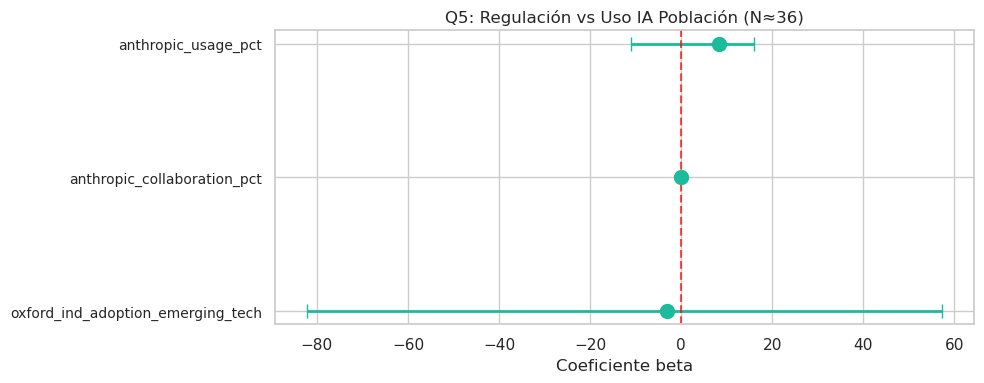


CONSISTENCIA Q5:
  n_binding: robust_negative (neg:2 pos:1 sig:1)
  n_non_binding: robust_negative (neg:3 pos:0 sig:1)
  n_hybrid: nan (neg:1 pos:2 sig:0)
  regulatory_intensity: robust_negative (neg:2 pos:1 sig:1)
  n_regulatory_mechanisms: robust_positive (neg:0 pos:3 sig:1)


In [18]:
q5 = pd.read_csv(OUTPUTS / "q5_results.csv")
q5_ols = q5[(q5["model"] == "OLS_full") & (q5["x_var"] != "const") & q5["coefficient"].notna()].copy()

focal = "n_binding_z" if "n_binding_z" in q5_ols["x_var"].unique() else "n_binding"
q5_focal = q5_ols[q5_ols["x_var"] == focal].sort_values("coefficient")

print("=" * 70)
print("Q5: RESULTADOS — Regulación vs Uso IA población (OLS_full)")
print("=" * 70)
print()
print(f"Variable X1: {focal}")
print(f"Modelos entrenados: 3 variables Y × 2 modelos = 6 ajustes")
print()

if len(q5_focal) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    y_pos = range(len(q5_focal))
    has_ci = q5_focal["ci95_lower"].notna().any()
    if has_ci:
        ax.errorbar(
            q5_focal["coefficient"], y_pos,
            xerr=[q5_focal["coefficient"] - q5_focal["ci95_lower"],
                  q5_focal["ci95_upper"] - q5_focal["coefficient"]],
            fmt="o", color="#1abc9c", ecolor="#1abc9c", elinewidth=2, capsize=5, markersize=10
        )
    ax.axvline(x=0, color="red", linestyle="--", alpha=0.7)
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels([y[:35] for y in q5_focal["y_var"]], fontsize=10)
    ax.set_xlabel("Coeficiente beta")
    n_eff = int(q5_focal["n_effective"].iloc[0])
    ax.set_title(f"Q5: Regulación vs Uso IA Población (N≈{n_eff})")
    plt.tight_layout()
    plt.show()

q5_cons = pd.read_csv(OUTPUTS / "q5_consistency.csv")
print()
print("CONSISTENCIA Q5:")
for _, row in q5_cons.iterrows():
    d = row.get("direction_summary", "N/A")
    print(f"  {row['x_var']}: {d} (neg:{int(row.get('n_y_negative',0))} pos:{int(row.get('n_y_positive',0))} sig:{int(row.get('n_y_significant_05',0))})")

---
## 9. Q6 — Uso de IA en Sector Público

### 9.1 ¿Qué pregunta responde?
**¿La regulación de IA se asocia con el uso de IA en el gobierno?**

### 9.2 ¿Qué países se usaron?

| Tier | Variables Y | N países |
|------|-------------|----------|
| **Primary** | 5 variables (e-government, digital policy, data governance, etc.) | 43 |
| **Auxiliary** | 1 variable (OECD digital gov overall) | 31 |

### 9.3 ¿Qué modelos se entrenaron y CÓMO?

Para **cada variable Y en cada tier**, se entrenaron 2 modelos:

#### Modelo A: OLS_full + bootstrap 2000
- Igual que Q1/Q3/Q5
- Train: todos los países con datos
- Validación: bootstrap 2000

#### Modelo B: Logistic (clasificación)
- Igual que Q2/Q5
- Y binarizada por mediana
- Validación: 5-fold CV x10 + LOOCV

Q6: RESULTADOS — Regulación vs Uso IA Sector Público (Tier Primary)

Variable X1: n_binding
Modelos entrenados: 5 Y primary × 2 modelos + 1 Y aux × 2 modelos = 12 ajustes



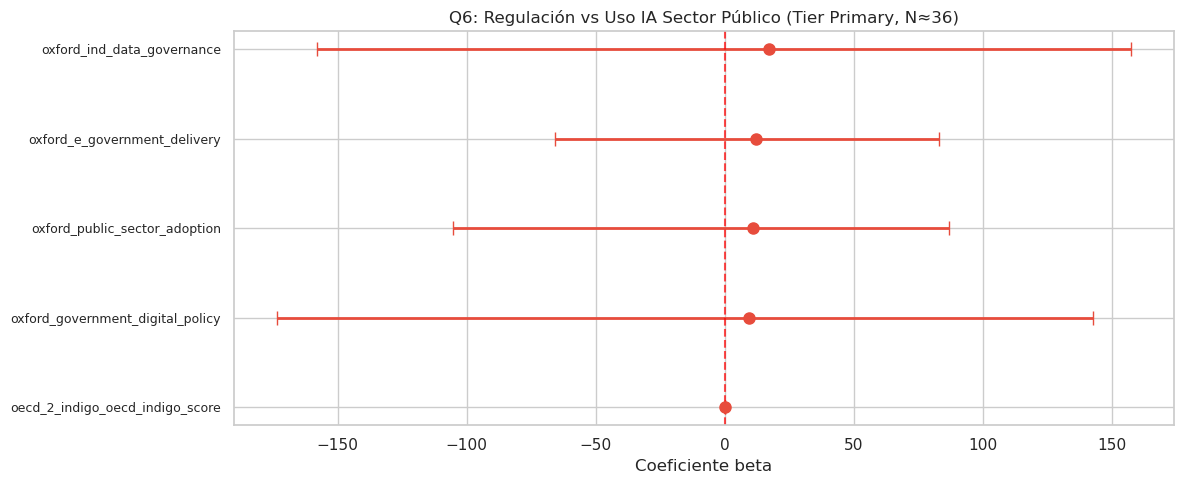


CONSISTENCIA Q6 (primary tier):
  n_binding: neg=0 pos=5 sig=0
  n_non_binding: neg=4 pos=1 sig=0
  n_hybrid: neg=3 pos=2 sig=0
  regulatory_intensity: neg=4 pos=1 sig=0
  n_regulatory_mechanisms: neg=1 pos=4 sig=0


In [19]:
q6 = pd.read_csv(OUTPUTS / "q6_results.csv")

focal = "n_binding_z" if "n_binding_z" in q6["x_var"].unique() else "n_binding"
q6_primary = q6[
    (q6["model"] == "OLS_full") &
    (q6["x_var"] == focal) &
    (q6["tier"] == "primary") &
    q6["coefficient"].notna()
].copy()
q6_primary = q6_primary.sort_values("coefficient")

print("=" * 70)
print("Q6: RESULTADOS — Regulación vs Uso IA Sector Público (Tier Primary)")
print("=" * 70)
print()
print(f"Variable X1: {focal}")
print(f"Modelos entrenados: 5 Y primary × 2 modelos + 1 Y aux × 2 modelos = 12 ajustes")
print()

if len(q6_primary) > 0:
    fig, ax = plt.subplots(figsize=(12, 5))
    y_pos = range(len(q6_primary))
    has_ci = q6_primary["ci95_lower"].notna().any()
    if has_ci:
        ax.errorbar(
            q6_primary["coefficient"], y_pos,
            xerr=[q6_primary["coefficient"] - q6_primary["ci95_lower"],
                  q6_primary["ci95_upper"] - q6_primary["coefficient"]],
            fmt="o", color="#e74c3c", ecolor="#e74c3c", elinewidth=2, capsize=5, markersize=8
        )
    ax.axvline(x=0, color="red", linestyle="--", alpha=0.7)
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels([y[:35] for y in q6_primary["y_var"]], fontsize=9)
    ax.set_xlabel("Coeficiente beta")
    n_eff = int(q6_primary["n_effective"].iloc[0])
    ax.set_title(f"Q6: Regulación vs Uso IA Sector Público (Tier Primary, N≈{n_eff})")
    plt.tight_layout()
    plt.show()

q6_cons = pd.read_csv(OUTPUTS / "q6_consistency.csv")
print()
print("CONSISTENCIA Q6 (primary tier):")
for _, row in q6_cons.iterrows():
    print(f"  {row['x_var']}: neg={int(row.get('n_y_negative',0))} pos={int(row.get('n_y_positive',0))} sig={int(row.get('n_y_significant_05',0))}")

In [20]:
# Chile vs peers (sector público)
q6_pred = pd.read_csv(OUTPUTS / "q6_predictions_per_country.csv")
if len(q6_pred) > 0:
    peers = ["CHL", "SGP", "EST", "IRL", "KOR", "URY"]
    chile_peers = q6_pred[(q6_pred["iso3"].isin(peers)) & (q6_pred["tier"] == "primary")]
    if len(chile_peers) > 0:
        print("=" * 70)
        print("Q6: CHILE vs PEERS — Uso IA Sector Público (in-sample)")
        print("=" * 70)
        print()
        pivot_peers = chile_peers.pivot_table(index="iso3", columns="y_var", values="p_high_public_sector_use")
        display(pivot_peers.round(3))
        print()
        print("Peers seleccionados: SGP (Singapur), EST (Estonia), IRL (Irlanda),")
        print("KOR (Corea del Sur), URY (Uruguay), CHL (Chile)")

Q6: CHILE vs PEERS — Uso IA Sector Público (in-sample)



y_var,oecd_2_indigo_oecd_indigo_score,oxford_e_government_delivery,oxford_government_digital_policy,oxford_ind_data_governance,oxford_public_sector_adoption
iso3,,,,,
CHL,0.171,0.352,0.456,1.000,0.437
EST,0.600,0.869,0.907,0.462,0.756
IRL,0.878,0.646,0.289,0.973,0.219
KOR,0.037,0.887,0.125,0.949,0.736
SGP,0.120,0.980,0.974,0.998,0.778
URY,0.162,0.254,0.173,0.278,0.206



Peers seleccionados: SGP (Singapur), EST (Estonia), IRL (Irlanda),
KOR (Corea del Sur), URY (Uruguay), CHL (Chile)


---
## 10. Síntesis: ¿Qué aprendimos del proceso de train?

### 10.1 Resumen del proceso de entrenamiento por sub-pregunta

| Sub-pregunta | Modelos | N países | Validación | ¿Usó países TEST? |
|--------------|---------|----------|------------|-------------------|
| **Q4** Clustering | K-Means + HCA | 43 y 18 | Silhouette score | Sí (todos) |
| **Q1** Inversión | OLS, Ridge, Lasso | 36-43 | Bootstrap 2000 + CV | Sí (si tienen datos) |
| **Q3** Innovación | OLS, Ridge, GBR | 26-42 | Bootstrap 2000 + CV | Sí (si tienen datos) |
| **Q2** Adopción | Logistic, Random Forest | 20-41 | 5-fold×10 + LOOCV (AUC) | Sí (si tienen datos) |
| **Q5** Uso población | OLS, Logistic | 35-43 | Bootstrap 2000 + CV (AUC) | Sí (si tienen datos) |
| **Q6** Sector público | OLS, Logistic | 31-43 | Bootstrap 2000 + CV (AUC) | Sí (si tienen datos) |

### 10.2 ¿Por qué los 9 países TEST aparecen en la tabla?

**NO fueron usados como "test" en Fase 6.** Fueron tratados igual que todos los demás:
si tenían datos para la variable Y, se incluyeron en el entrenamiento.

La razón: con solo 43 países, reservar 9 para test haría que los modelos tuvieran muy pocos
datos para aprender. La validación con CV es más apropiada para muestras pequeñas.

### 10.3 ¿Cuándo se usarán los 9 países TEST?

En la **Fase 7 (Sensitivity Analysis):**
- Se entrenarán modelos SIN los países TEST
- Luego se verificará si las predicciones para los 9 países TEST son coherentes
- Esto dará una medida de "generalización" verdadera

### 10.4 ¿Chile participó en el entrenamiento?

**Sí.** Chile está en el grupo TRAIN y tiene datos para la mayoría de las variables.
Por lo tanto, Chile fue incluido en el entrenamiento de todos los modelos donde tuviera datos.

**Advertencia importante:** Las predicciones "in-sample" (como las probabilidades de Q2/Q5/Q6)
NO son una prueba independiente del modelo, porque Chile participó en el entrenamiento.
Sirven para posicionar a Chile relativamente, no para probar el modelo.

In [21]:
print("=" * 70)
print("SÍNTESIS: ASOCIACIÓN DE REGULACIÓN CON ECOSISTEMA")
print("=" * 70)
print()
print("n_binding = número de leyes vinculantes de IA en el país")
print()

summary_rows = []
for q_name, q_file, tier_filter in [
    ("Q1 Inversión", "q1_consistency.csv", None),
    ("Q3 Innovación", "q3_consistency.csv", "primary"),
    ("Q5 Uso población", "q5_consistency.csv", None),
    ("Q6 Sector público", "q6_consistency.csv", "primary"),
]:
    try:
        cons = pd.read_csv(OUTPUTS / q_file)
        if tier_filter and "tier" in cons.columns:
            cons = cons[cons["tier"] == tier_filter]
        if len(cons) > 0:
            row = cons.iloc[0]
            summary_rows.append({
                "Sub-pregunta": q_name,
                "Dirección": row.get("direction_summary", "N/A"),
                "Y negativos": int(row.get("n_y_negative", 0)),
                "Y positivos": int(row.get("n_y_positive", 0)),
                "Sig. (p<0.05)": int(row.get("n_y_significant_05", 0)),
            })
    except Exception as e:
        pass

if summary_rows:
    display(pd.DataFrame(summary_rows))

print()
print("DECISIONES TÉCNICAS CLAVE APLICADAS:")
print("  • Bootstrap 2000 iteraciones para IC95 (Decisión B, D)")
print("  • FDR Benjamini-Hochberg para corrección múltiple (Decisión E)")
print("  • Hiperparámetros fijos, NO GridSearch (Decisión F)")
print("  • PCA excluido del scope (Decisión L)")
print("  • Lenguaje 'asociación' por defecto, NO causalidad (Decisión I)")
print()
print("PRÓXIMOS PASOS:")
print("  • Fase 7: Sensitivity analysis (excluir AI leaders, comparar baseline)")
print("  • Fase 7: Usar los 9 países TEST para evaluación de generalización")
print("  • Fase 7: Hyperparameter robustness check")
print("  • Fase 8: Reporte ejecutivo + Excel final")

SÍNTESIS: ASOCIACIÓN DE REGULACIÓN CON ECOSISTEMA

n_binding = número de leyes vinculantes de IA en el país



,Sub-pregunta,Dirección,Y negativos,Y positivos,Sig. (p<0.05)
0,Q1 Inversión,mixed,3,3,3
1,Q3 Innovación,N/A,0,6,0
2,Q5 Uso población,robust_negative,2,1,1
3,Q6 Sector público,N/A,0,5,0



DECISIONES TÉCNICAS CLAVE APLICADAS:
  • Bootstrap 2000 iteraciones para IC95 (Decisión B, D)
  • FDR Benjamini-Hochberg para corrección múltiple (Decisión E)
  • Hiperparámetros fijos, NO GridSearch (Decisión F)
  • PCA excluido del scope (Decisión L)
  • Lenguaje 'asociación' por defecto, NO causalidad (Decisión I)

PRÓXIMOS PASOS:
  • Fase 7: Sensitivity analysis (excluir AI leaders, comparar baseline)
  • Fase 7: Usar los 9 países TEST para evaluación de generalización
  • Fase 7: Hyperparameter robustness check
  • Fase 8: Reporte ejecutivo + Excel final


---
## 11. Verificación final

Confirmamos que todos los archivos de salida existen y que este notebook
NO modificó ningún dato.

In [22]:
with open(OUTPUTS / "fase6_manifest.json") as f:
    manifest = json.load(f)

print("=" * 70)
print("VERIFICACIÓN FINAL")
print("=" * 70)
print()
print("Outputs generados:", len(manifest["outputs"]))
print("Seed:", manifest["seed"])
print("Bootstrap:", manifest["n_bootstrap"])
print("Decisiones aplicadas:", len(manifest["decisions_log"]))
print()
print("Archivos verificados:")
for fname in sorted(manifest["outputs"].keys()):
    print(f"  ✓ {fname}")
print()
print("=" * 70)
print("ESTE NOTEBOOK NO RECALCULÓ NINGÚN MODELO.")
print("SOLO LEE CSVs PARA AUDITORÍA HUMANA.")
print("=" * 70)

VERIFICACIÓN FINAL

Outputs generados: 19
Seed: 42
Bootstrap: 2000
Decisiones aplicadas: 11

Archivos verificados:
  ✓ q1_consistency.csv
  ✓ q1_psm_balance_diagnostics.csv
  ✓ q1_psm_matched_pairs.csv
  ✓ q1_results.csv
  ✓ q2_predictions_per_country.csv
  ✓ q2_results.csv
  ✓ q3_consistency.csv
  ✓ q3_results.csv
  ✓ q4_centroids.csv
  ✓ q4_clusters.csv
  ✓ q4_distance_matrix_n18.csv
  ✓ q4_distance_matrix_n43.csv
  ✓ q4_silhouette_scores.csv
  ✓ q5_consistency.csv
  ✓ q5_predictions_per_country.csv
  ✓ q5_results.csv
  ✓ q6_consistency.csv
  ✓ q6_predictions_per_country.csv
  ✓ q6_results.csv

ESTE NOTEBOOK NO RECALCULÓ NINGÚN MODELO.
SOLO LEE CSVs PARA AUDITORÍA HUMANA.
